# 22 - accDM: fractional error in H from the acceleration equation

In GR the two Friedmann equations are not independent. Carry the second one as an auxiliary variable

$$\frac{\mathrm{d}\mathcal{H}_B}{\mathrm{d}\tau} = -\frac{4\pi G}{3}\,a^2\bigl(\rho_{\rm tot}+3p_{\rm tot}\bigr),
\qquad \mathcal{H}_B(\tau_{\rm ini}) = \mathcal{H}_A(\tau_{\rm ini}),$$

starting well before $a_t$, and compare against $\mathcal{H}_A = aH$, the value CLASS actually uses. Then define

$$\Delta(a) \;=\; \frac{\mathcal{H}_B(a)-\mathcal{H}_A(a)}{\mathcal{H}_A(a)},$$

the accumulated fractional error in the expansion rate. To leading order
$\mathcal{H}_B^2-\mathcal{H}_A^2 = -K^{\rm eff}$, hence $\Delta \simeq -\tfrac12\Omega_K^{\rm eff}$


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from classy import Class

plt.rcParams.update({
    'mathtext.fontset': 'stix',
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'legend.fontsize': 9,
    'lines.linewidth': 1.5,
    'figure.dpi': 300,
})
qual_colors = ['#377eb8', '#ff7f00', '#4daf4a', '#f781bf', '#984ea3', '#a65628']

# ---- Planck 2018 base cosmology ---------------------------------------------
omega_b     = 0.022383
omega_cdm0  = 0.12011
A_s         = 2.1005829616811546e-9
n_s         = 0.96605
tau_reio    = 0.0543
H0          = 67.32
base_params = {'omega_b': omega_b, 'omega_cdm': omega_cdm0, 'H0': H0,
               'A_s': A_s, 'n_s': n_s, 'tau_reio': tau_reio}

A_REC = 1.0/(1.0 + 1090.0)

N_LOGA       = 10001    # CLASS ln a grid
N_Q_DAUGHTER = 10001     # daughter q-bins; D3 is insensitive to this (checked in section 2)
A_START      = 1e-3     # start the integration here: well before any a_t scanned below


def accdm_params(f_acc, eta, kappa, a_t, mass_GeV=1e16, n_q=None):
    '''The accDM parent is ADDED on top of omega_cdm in the code, so omega_cdm is
    rescaled to hold the total matter budget fixed (same convention as
    notebooks_test/3_test_bg_conservation.ipynb).'''
    n_q  = N_Q_DAUGHTER if n_q is None else n_q
    ocdm = omega_cdm0*(1 + f_acc*(1 - A_REC**kappa)/(1 + (A_REC/a_t)**kappa))**(-1)
    p = dict(base_params)
    p.update({'omega_cdm': ocdm,
              'vary_Gamma_acc': 'yes', 'kappa_acc': kappa, 'a_t_acc': a_t,
              'f_acc': f_acc, 'eta_acc': eta,
              'm_acc_in_GeV': mass_GeV, 'm_cdm_in_GeV': mass_GeV,
              'N_ncdm': 2, 'deg_ncdm': '3, 1',
              'm_ncdm': '0.02, {:.6e}'.format(mass_GeV*1e9),
              'T_ncdm': '0.71611, 1',
              'ncdm_quadrature_strategy': '0, 4',
              'ncdm_N_momentum_bins': '15, {:d}'.format(n_q),
              'N_ur': 0.00441,
              'background_Nloga': N_LOGA})
    return p


def lcdm_params():
    '''Matched LCDM: same neutrino sector, same grid, no accDM. The null test.'''
    p = dict(base_params)
    p.update({'N_ncdm': 1, 'deg_ncdm': '3', 'm_ncdm': '0.02',
              'T_ncdm': '0.71611', 'ncdm_quadrature_strategy': '0',
              'ncdm_N_momentum_bins': '15', 'N_ur': 0.00441,
              'background_Nloga': N_LOGA})
    return p


def run_background(params):
    '''Background + thermodynamics only (no output= key) -> seconds, not minutes.'''
    cosmo = Class()
    cosmo.set(params)
    cosmo.compute()
    bg = cosmo.get_background()
    cosmo.struct_cleanup()
    cosmo.empty()
    return bg


print('setup ready. ln a grid = {:d}, daughter q-bins = {:d}, A_START = {:g}'.format(
      N_LOGA, N_Q_DAUGHTER, A_START))


setup ready. ln a grid = 10001, daughter q-bins = 10001, A_START = 0.001


In [15]:
try:
    from scipy.interpolate import CubicSpline
    HAVE_SCIPY = True
except ImportError:
    HAVE_SCIPY = False


def cumtrapz0(y, x):
    return np.concatenate(([0.0], np.cumsum(0.5*(y[1:] + y[:-1])*np.diff(x))))


def cum_euler_maclaurin(y, x):
    '''Cumulative trapezoid with the Euler-Maclaurin end correction: O(h^4) on a
    uniform grid, int = T - (h^2/12)[f'(b) - f'(a)] + O(h^4).'''
    h = float(np.median(np.diff(x)))
    dy = np.gradient(y, x)
    return cumtrapz0(y, x) - (h*h/12.0)*(dy - dy[0])


def cum_spline(y, x):
    '''Cumulative integral as the antiderivative of a cubic spline: O(h^4).'''
    F = CubicSpline(x, y).antiderivative()
    return F(x) - F(x[0])


def cum_best(y, x):
    return cum_spline(y, x) if HAVE_SCIPY else cum_euler_maclaurin(y, x)


def analytic_lcdm_selftest(a_start=A_START, n=20001, Om=0.31, Or=9.1e-5, OL=0.68991):
    '''Unit test of the integrand on an ANALYTIC flat LCDM background (H0 = 1).
    Nothing from CLASS enters, so a sign or factor error shows up immediately.'''
    x   = np.linspace(np.log(a_start), 0.0, n)
    a   = np.exp(x)
    rho = Om/a**3 + Or/a**4 + OL
    p   = Or/(3.0*a**4) - OL
    Hcal_A = a*np.sqrt(rho)
    dHB_dx = -(a**2)*(rho + 3.0*p)/(2.0*Hcal_A)
    Hcal_B = Hcal_A[0] + cum_best(dHB_dx, x)
    return float(np.max(np.abs(Hcal_B/Hcal_A - 1.0)))


def acceleration_integration(bg, a_start=A_START):
    '''Integrate Friedmann II alongside the code's solution and compare.

    CLASS units: (.)rho = (8 pi G/3) rho_phys [Mpc^-2], H is the PROPER rate, and
    for K = 0 the constraint reads H^2 = rho_tot, so Hcal_A = a*H and
    dHcal_B/dtau = -(1/2) a^2 (rho_tot + 3 p_tot).
    '''
    a_all = 1.0/(1.0 + np.asarray(bg['z']))
    order = np.argsort(a_all)
    take  = lambda key: np.asarray(bg[key])[order]

    a, H   = a_all[order], take('H [1/Mpc]')
    rho, p = take('(.)rho_tot'), take('(.)p_tot')
    tau    = take('conf. time [Mpc]')

    units_residual = float(np.max(np.abs(H**2/rho - 1.0)))   # Friedmann closure

    sel = a >= a_start
    a, H, rho, p, tau = a[sel], H[sel], rho[sel], p[sel], tau[sel]
    x = np.log(a)
    Hcal_A = a*H

    dHB_dx     = -(a**2)*(rho + 3.0*p)/(2.0*Hcal_A)     # (dHcal_B/dtau)*(dtau/dx)
    Hcal_B     = Hcal_A[0] + cum_best(dHB_dx, x)
    Hcal_B_alt = Hcal_A[0] + cum_euler_maclaurin(dHB_dx, x)
    Delta      = Hcal_B/Hcal_A - 1.0

    # differentiation-free check of the Jacobian: rebuild the table's own tau column
    tau_recon    = tau[0] + cum_best(1.0/Hcal_A, x)
    tau_selftest = float(np.max(np.abs(tau_recon[1:]/tau[1:] - 1.0)))

    return dict(a=a, x=x, Hcal_A=Hcal_A, Hcal_B=Hcal_B, Delta=Delta,
                D=Hcal_A - Hcal_B, Icum=cum_best(Hcal_A, x),
                units_residual=units_residual, tau_selftest=tau_selftest,
                quad_spread=float(np.max(np.abs(Hcal_B_alt/Hcal_A - 1.0 - Delta))))


def windowed_R(acc, half_width_efolds=0.05):
    '''Exact Hcal_A-weighted window mean of the pointwise residual R, which the
    decision table is keyed to. Since d(Hcal_A - Hcal_B)/dx = R*Hcal_A,

        R_bar = [Hcal_A - Hcal_B] over the window / int Hcal_A dx

    is exact and needs no derivative.'''
    x, D, Icum = acc['x'], acc['D'], acc['Icum']
    dx = float(np.median(np.diff(x)))
    m  = max(1, int(round(half_width_efolds/dx)))
    i  = np.arange(m, len(x) - m)
    return acc['a'][i], (D[i + m] - D[i - m])/(Icum[i + m] - Icum[i - m])


def omega_k_eff_legacy(bg, a_start):
    '''The older K_eff estimator. Present ONLY for the conditioning comparison in
    section 1; it is not used for any reported number.'''
    a_all = 1.0/(1.0 + np.asarray(bg['z']))
    order = np.argsort(a_all)
    take  = lambda key: np.asarray(bg[key])[order]
    a, H   = a_all[order], take('H [1/Mpc]')
    rho, p = take('(.)rho_tot'), take('(.)p_tot')
    sel = a >= a_start
    a, H, rho, p = a[sel], H[sel], rho[sel], p[sel]
    x = np.log(a)
    C = a**2*rho + cum_euler_maclaurin(a**2*(rho + 3.0*p), x)
    return float((C[-1] - C[0])/(a[-1]*H[-1])**2)


selftest = analytic_lcdm_selftest()
print('quadrature: {}'.format('cubic-spline antiderivative, O(h^4)' if HAVE_SCIPY
                              else 'Euler-Maclaurin trapezoid, O(h^4)'))
print('analytic LCDM unit test: max|Delta| = {:.3e}  ->  {}'.format(
      selftest, 'signs and factors CORRECT' if selftest < 1e-9 else 'FORMULA IS WRONG'))
assert selftest < 1e-9, 'the integrand fails on an analytic LCDM background'


quadrature: cubic-spline antiderivative, O(h^4)
analytic LCDM unit test: max|Delta| = 3.881e-12  ->  signs and factors CORRECT


## 1. Null test - LCDM

Run this first. On a model that is conserved by construction, $\Delta$ must sit at quadrature level.
If it does not, the estimator is broken and nothing below means anything.

Three separate checks:

- **Friedmann closure** $\max|H^2/\rho_{\rm tot}-1|$ - confirms the units assumption ($K=0$,
  densities carry $8\pi G/3$). Expect $\sim10^{-16}$.
- **Conformal-time reconstruction** - rebuilds the table's `conf. time [Mpc]` column from
  $\int\mathrm{d}x/\mathcal{H}_A$. Validates the Jacobian and the quadrature, no derivatives.
- **$\Delta(a=1)$** - the noise floor every accDM number is quoted against.

The `A_START` scan prints this estimator next to the older $K^{\rm eff}$ one at the same start
points, so the one-power-of-$a_i$ conditioning claim is checked on the real table.


In [16]:
bg_lcdm  = run_background(lcdm_params())
acc_lcdm = acceleration_integration(bg_lcdm)

print('LCDM NULL TEST')
print('  rows used                : {:d}  (a >= {:g})'.format(len(acc_lcdm['a']), A_START))
print('  Friedmann closure        : {:.3e}   max|H^2/rho_tot - 1|'.format(acc_lcdm['units_residual']))
print('  conf-time reconstruction : {:.3e}   int dx/Hcal_A vs the tau column'.format(
      acc_lcdm['tau_selftest']))
print('  quadrature spread        : {:.3e}   spline vs Euler-Maclaurin'.format(acc_lcdm['quad_spread']))
print('  Delta(a=1)               : {:+.3e}   <- NULL FLOOR'.format(float(acc_lcdm['Delta'][-1])))
print('  max |Delta(a)|           : {:.3e}'.format(float(np.max(np.abs(acc_lcdm['Delta'])))))

a_rn, R_null = windowed_R(acc_lcdm)
print('  max |R_windowed|         : {:.3e}   <- NULL FLOOR for R'.format(float(np.max(np.abs(R_null)))))

NULL_DELTA = abs(float(acc_lcdm['Delta'][-1]))
NULL_R     = float(np.max(np.abs(R_null)))

print('\n  A_START sensitivity - conditioning vs the older K_eff estimator:')
print('  {:>10} {:>16} {:>18} {:>10}'.format('A_START', 'this |Delta(1)|', 'legacy |OmK(1)|/2', 'ratio'))
prev = None
for a0 in (1e-5, 1e-4, 1e-3, 1e-2):
    d_new = abs(float(acceleration_integration(bg_lcdm, a_start=a0)['Delta'][-1]))
    d_old = 0.5*abs(omega_k_eff_legacy(bg_lcdm, a0))
    line = '  {:>10.0e} {:>16.3e} {:>18.3e} {:>10.1f}'.format(a0, d_new, d_old, d_old/max(d_new, 1e-300))
    if prev is not None:
        line += '   (per decade: this x{:.1f}, legacy x{:.1f})'.format(prev[0]/d_new, prev[1]/d_old)
    print(line)
    prev = (d_new, d_old)

ok = acc_lcdm['units_residual'] < 1e-10 and acc_lcdm['tau_selftest'] < 1e-6
print('\nNULL TEST:', 'PASS' if ok else 'FAIL')
assert ok, 'units or Jacobian self-test failed - fix the estimator before reading anything else'


LCDM NULL TEST
  rows used                : 2143  (a >= 0.001)
  Friedmann closure        : 2.220e-16   max|H^2/rho_tot - 1|
  conf-time reconstruction : 3.605e-10   int dx/Hcal_A vs the tau column
  quadrature spread        : 1.404e-08   spline vs Euler-Maclaurin
  Delta(a=1)               : +1.414e-12   <- NULL FLOOR
  max |Delta(a)|           : 1.608e-12
  max |R_windowed|         : 9.682e-13   <- NULL FLOOR for R

  A_START sensitivity - conditioning vs the older K_eff estimator:
     A_START  this |Delta(1)|  legacy |OmK(1)|/2      ratio
       1e-05        1.355e-10          5.148e-03 37990467.3
       1e-04        1.335e-11          5.355e-05  4011162.2   (per decade: this x10.2, legacy x96.1)
       1e-03        1.414e-12          7.262e-07   513666.3   (per decade: this x9.4, legacy x73.7)
       1e-02        1.459e-13          2.341e-08   160464.7   (per decade: this x9.7, legacy x31.0)

NULL TEST: PASS


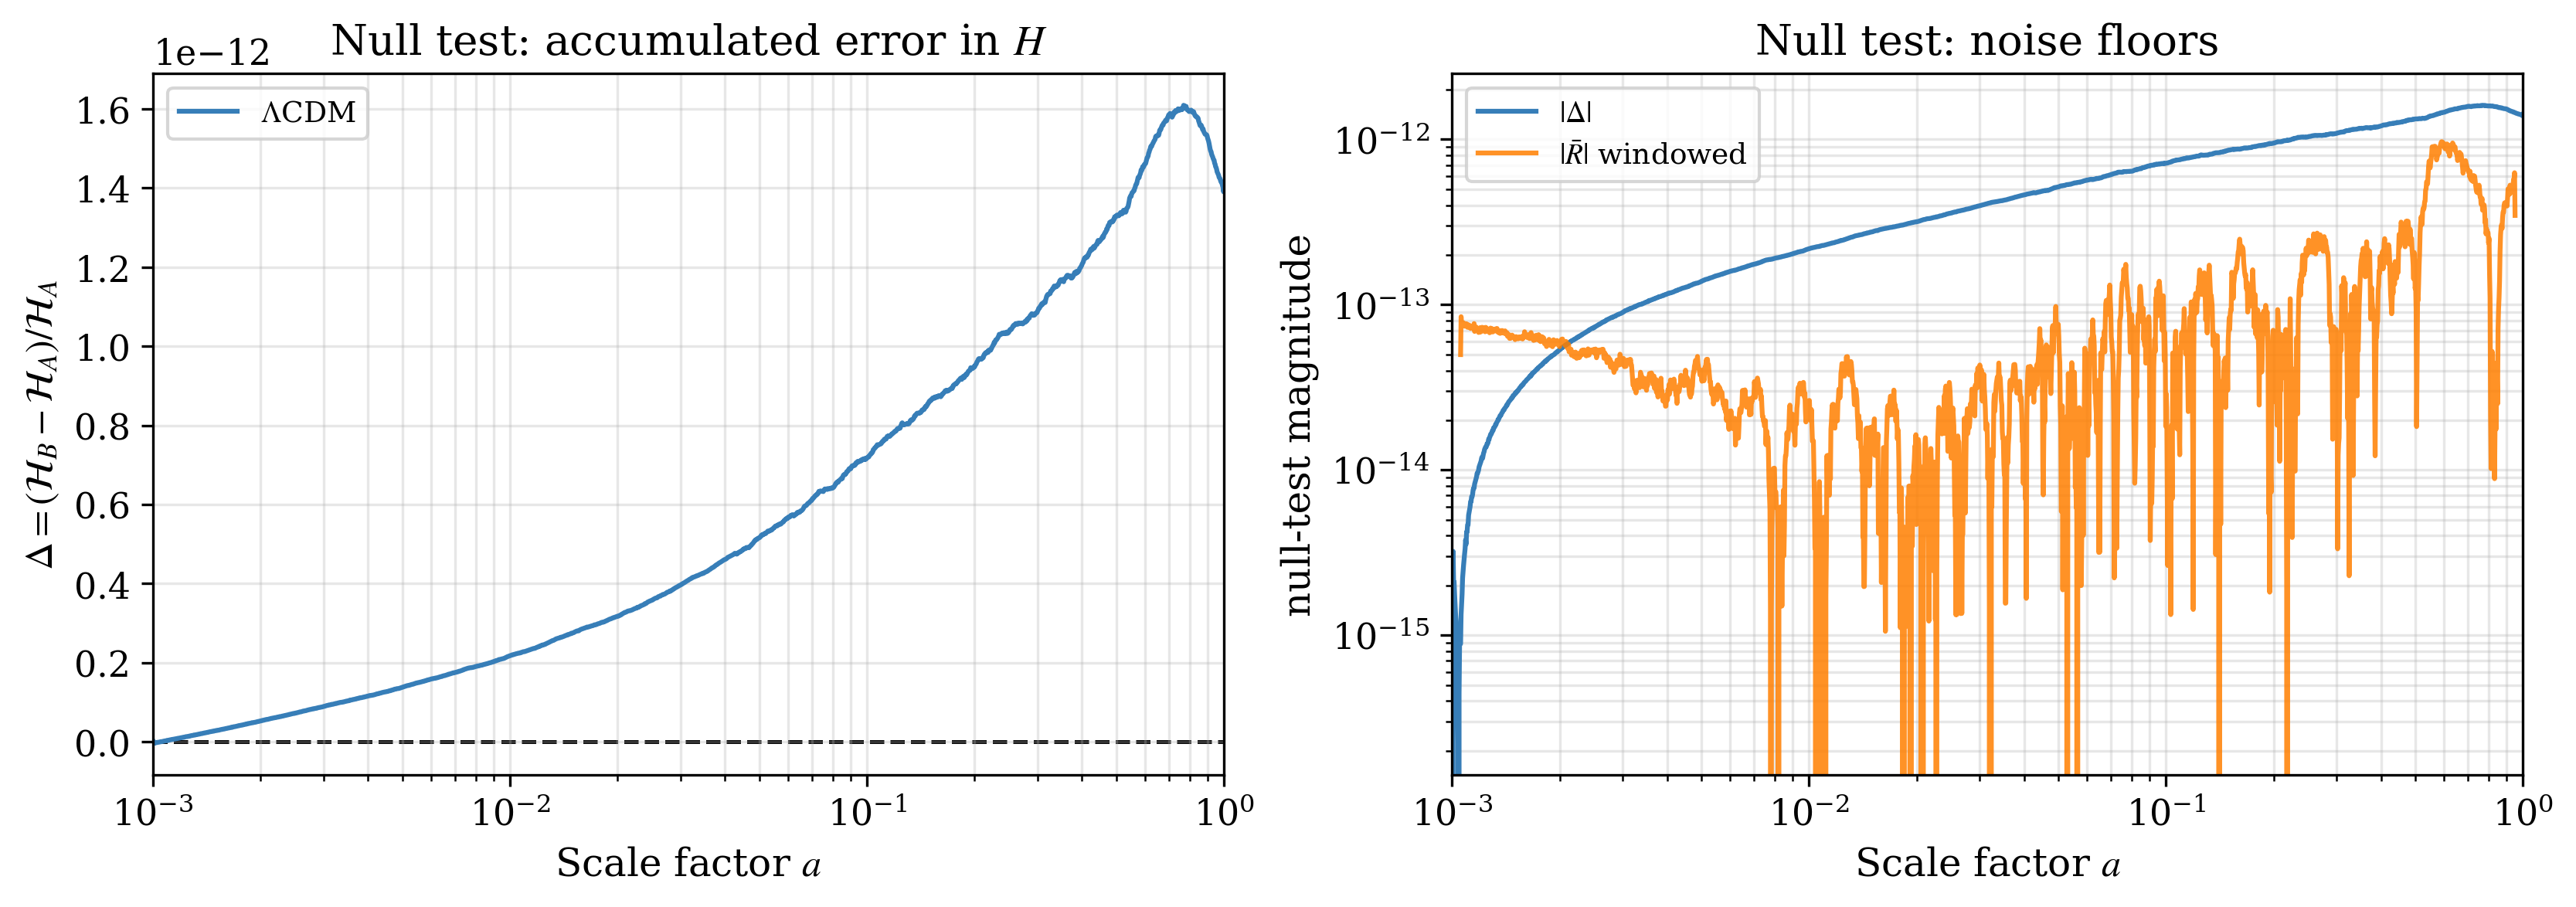

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), constrained_layout=True)

ax = axes[0]
ax.semilogx(acc_lcdm['a'], acc_lcdm['Delta'], color=qual_colors[0], label=r'$\Lambda$CDM')
ax.axhline(0.0, color='black', linestyle='--', linewidth=1.2, zorder=1)
ax.set_xlim(A_START, 1.0)
ax.set_xlabel(r'Scale factor $a$')
ax.set_ylabel(r'$\Delta = (\mathcal{H}_B-\mathcal{H}_A)/\mathcal{H}_A$')
ax.set_title('Null test: accumulated error in $H$')
ax.legend(loc='best')
ax.grid(True, which='both', alpha=0.3)

ax = axes[1]
ax.loglog(acc_lcdm['a'], np.abs(acc_lcdm['Delta']), color=qual_colors[0], label=r'$|\Delta|$')
ax.loglog(a_rn, np.abs(R_null), color=qual_colors[1], alpha=0.85, label=r'$|\bar R|$ windowed')
ax.set_xlim(A_START, 1.0)
ax.set_xlabel(r'Scale factor $a$')
ax.set_ylabel('null-test magnitude')
ax.set_title('Null test: noise floors')
ax.legend(loc='best')
ax.grid(True, which='both', alpha=0.3)

plt.show()


## 2. accDM

`SCAN_POINTS` is editable. The second entry uses the code's own default
$\eta = 10^{11}/m_{\rm acc}$ (`input.c:2643`); the third is an aggressive corner to bracket the prior
volume. Replace them with your actual prior ranges before quoting anything.

The q-grid check that follows re-runs the fiducial point with a 10x smaller daughter momentum grid.
Because nothing is differentiated, $\Delta$ should barely move - which is the practical advantage of
this formulation over anything built on $\mathrm{d}H/\mathrm{d}\ln a$.


In [18]:
FIDUCIAL = dict(f_acc=0.1, eta=0.1, kappa=12.1, a_t=0.133)

SCAN_POINTS = [
    ('eta = 1.0',  dict(f_acc=0.1, eta=1.0,  kappa=12.1, a_t=0.133)),
    ('eta = 0.5',  dict(f_acc=0.1, eta=0.5,  kappa=12.1, a_t=0.133)),
    ('eta = 0.1',  dict(f_acc=0.1, eta=0.1,  kappa=12.1, a_t=0.133)),
    ('eta = 1e-2', dict(f_acc=0.1, eta=1e-2, kappa=12.1, a_t=0.133)),
    ('eta = 1e-3', dict(f_acc=0.1, eta=1e-3, kappa=12.1, a_t=0.133)),
    ('eta = 1e-4', dict(f_acc=0.1, eta=1e-4, kappa=12.1, a_t=0.133)),
    ('eta = 1e-5', dict(f_acc=0.1, eta=1e-5, kappa=12.1, a_t=0.133)),
    ('eta = 1e-6', dict(f_acc=0.1, eta=1e-6, kappa=12.1, a_t=0.133)),
    # ('aggressive corner',      dict(f_acc=1.0, eta=0.5,  kappa=12.1, a_t=0.133)),
    # ('a_t = 0.02',             dict(f_acc=0.1, eta=0.1,  kappa=12.1, a_t=0.02)),
    # ('a_t = 0.05',             dict(f_acc=0.1, eta=0.1,  kappa=12.1, a_t=0.05)),
    # ('a_t = 0.40',             dict(f_acc=0.1, eta=0.1,  kappa=12.1, a_t=0.40)),
]

results = {}
print('running {:d} background points...'.format(len(SCAN_POINTS)))
for label, pars in SCAN_POINTS:
    acc = acceleration_integration(run_background(accdm_params(**pars)))
    a_w, R_w = windowed_R(acc)
    i_peak = int(np.argmax(np.abs(R_w)))
    results[label] = dict(pars=pars, acc=acc, a_win=a_w, R_win=R_w,
                          Delta1=float(acc['Delta'][-1]),
                          R_max=float(np.abs(R_w[i_peak])),
                          a_at_max=float(a_w[i_peak]))
    print('  done: {:<24} Delta(1) = {:+.4e}'.format(label, results[label]['Delta1']))

print()
print('{:<24} {:>7} {:>8} {:>7} {:>7} {:>14} {:>9} {:>12} {:>9}'.format(
      'point', 'f_acc', 'eta', 'kappa', 'a_t', 'Delta(1)', 'S/N', 'max|R|', 'at a'))
print('-' * 106)
for label, pars in SCAN_POINTS:
    r = results[label]
    print('{:<24} {:>7.2f} {:>8.1e} {:>7.1f} {:>7.3f} {:>+14.4e} {:>9.1e} {:>12.4e} {:>9.4f}'.format(
          label, pars['f_acc'], pars['eta'], pars['kappa'], pars['a_t'],
          r['Delta1'], abs(r['Delta1'])/max(NULL_DELTA, 1e-300), r['R_max'], r['a_at_max']))

print()
print('LCDM null floors      : Delta(1) = {:+.3e}   max|R| = {:.3e}'.format(
      float(acc_lcdm['Delta'][-1]), NULL_R))
print('Planck 2018 + BAO     : Omega_K = 0.0007 +/- 0.0019, so |Delta| = 9.5e-4 is 1 sigma')
print('Sign convention       : Delta < 0 means the code expands FASTER than the')
print('                        acceleration equation allows - what creating energy does.')


running 8 background points...
  done: eta = 1.0                Delta(1) = -5.7932e-02
  done: eta = 0.5                Delta(1) = -2.9175e-02
  done: eta = 0.1                Delta(1) = -5.8704e-03
  done: eta = 1e-2               Delta(1) = -5.9044e-04
  done: eta = 1e-3               Delta(1) = -6.1726e-05
  done: eta = 1e-4               Delta(1) = -8.8475e-06
  done: eta = 1e-5               Delta(1) = -3.5596e-06
  done: eta = 1e-6               Delta(1) = -3.0308e-06

point                      f_acc      eta   kappa     a_t       Delta(1)       S/N       max|R|      at a
----------------------------------------------------------------------------------------------------------
eta = 1.0                   0.10  1.0e+00    12.1   0.133    -5.7932e-02   4.1e+10   1.1608e-01    0.1325
eta = 0.5                   0.10  5.0e-01    12.1   0.133    -2.9175e-02   2.1e+10   6.1092e-02    0.1325
eta = 0.1                   0.10  1.0e-01    12.1   0.133    -5.8704e-03   4.2e+09   1.5838e-02

In [19]:
# q-grid insensitivity: the daughter's momentum bins switch on one at a time, so
# rho_ncdm is a staircase. An integrated diagnostic should not care.
print('daughter q-grid check at the fiducial point (nothing is differentiated, so')
print('Delta should be nearly independent of the number of bins):')
print('  {:>10} {:>16}'.format('q-bins', 'Delta(1)'))
q_check = {}
for n_q in (201, N_Q_DAUGHTER):
    acc_q = acceleration_integration(run_background(accdm_params(n_q=n_q, **FIDUCIAL)))
    q_check[n_q] = float(acc_q['Delta'][-1])
    print('  {:>10d} {:>+16.6e}'.format(n_q, q_check[n_q]))
lo, hi = q_check[201], q_check[N_Q_DAUGHTER]
print('  fractional change over a {:.0f}x change in q-grid: {:.2e}'.format(
      N_Q_DAUGHTER/201.0, abs(lo/hi - 1.0)))


daughter q-grid check at the fiducial point (nothing is differentiated, so
Delta should be nearly independent of the number of bins):
      q-bins         Delta(1)
         201    +1.450549e-03
       10001    -5.870392e-03
  fractional change over a 50x change in q-grid: 1.25e+00


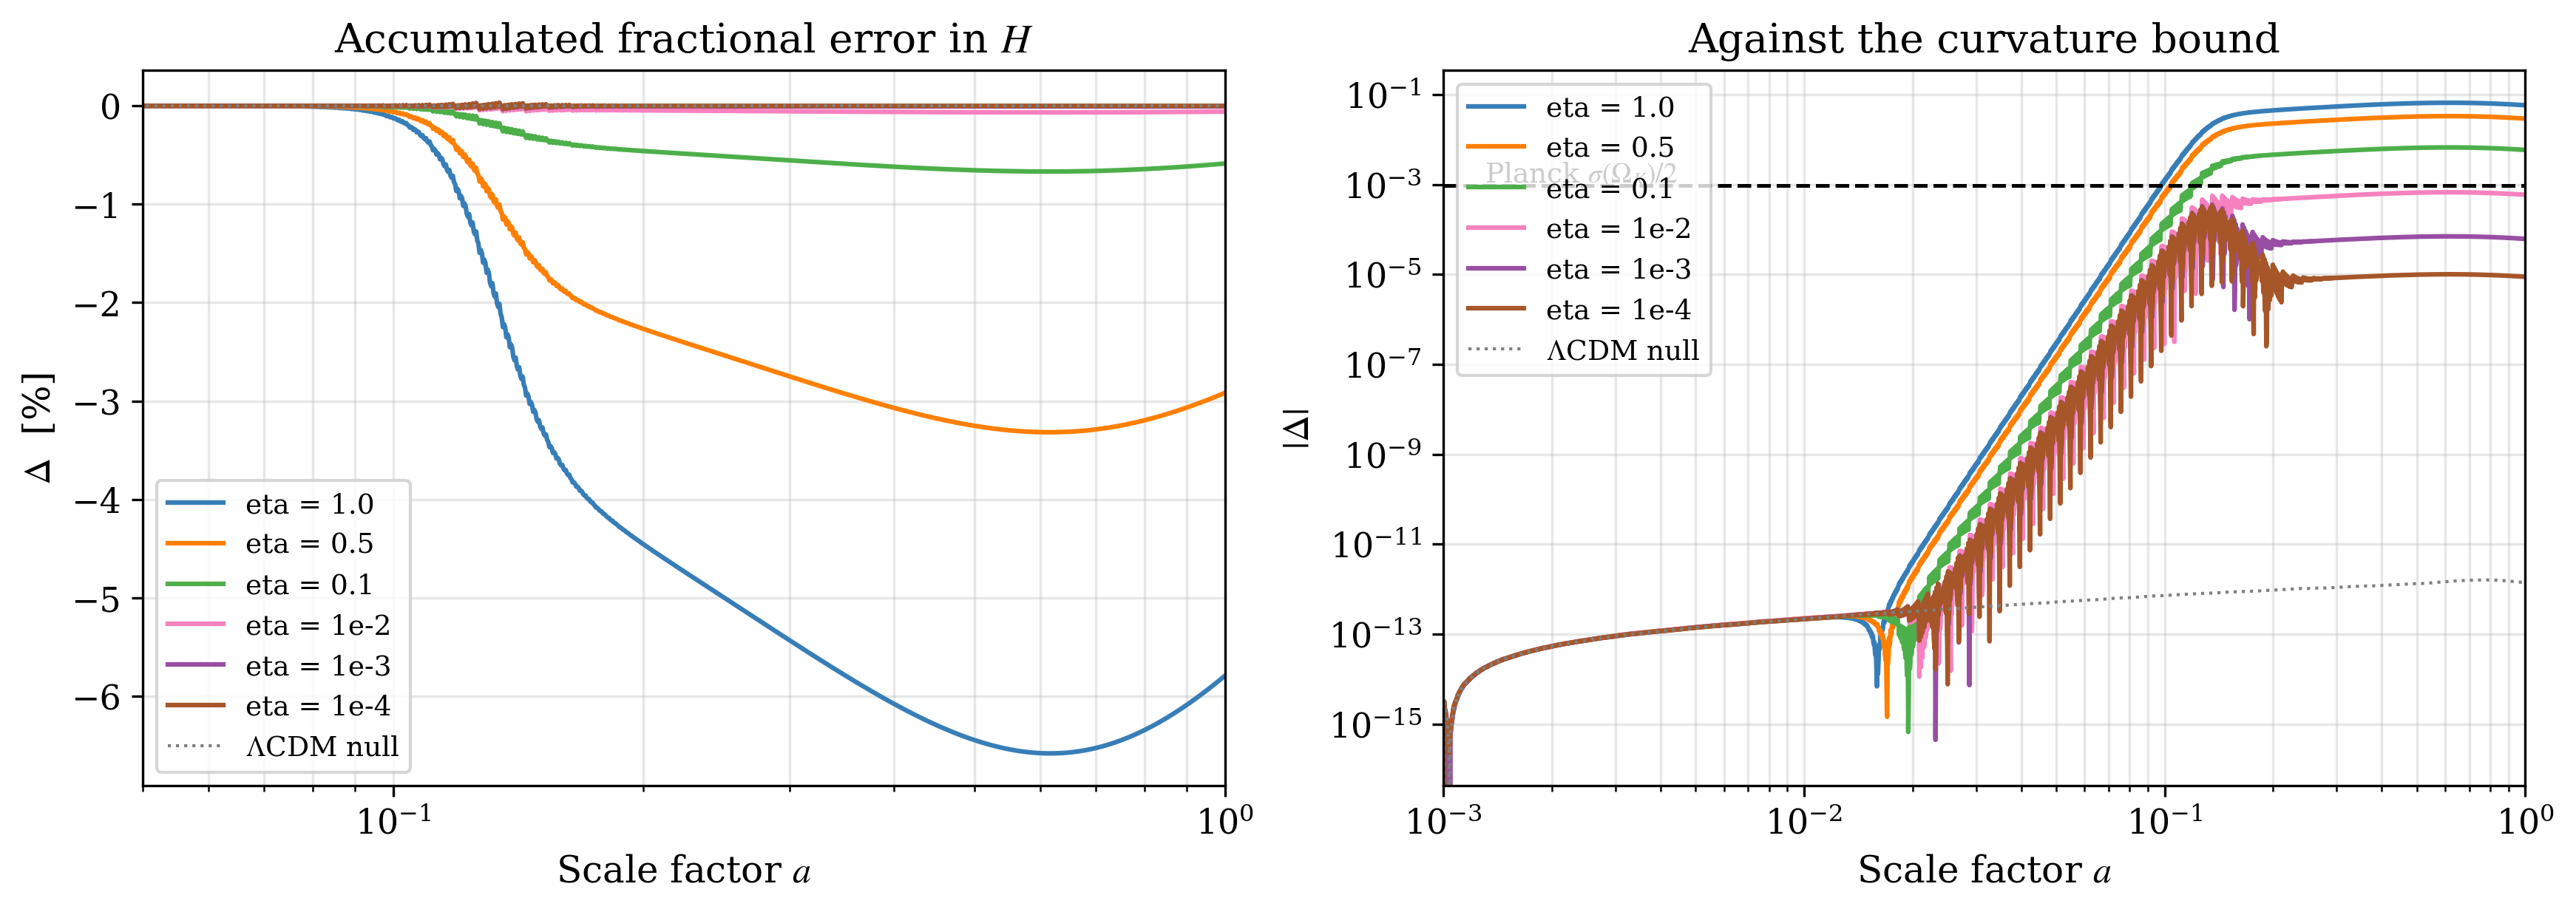

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0), constrained_layout=True)

ax = axes[0]
for color, (label, _) in zip(qual_colors, SCAN_POINTS):
    r = results[label]
    ax.semilogx(r['acc']['a'], 100.0*r['acc']['Delta'], color=color, label=label)
ax.semilogx(acc_lcdm['a'], 100.0*acc_lcdm['Delta'], color='0.5', linestyle=':',
            linewidth=1.0, label=r'$\Lambda$CDM null')
ax.axhline(0.0, color='black', linestyle='--', linewidth=1.2, zorder=1)
ax.set_xlim(5e-2, 1.0)
ax.set_xlabel(r'Scale factor $a$')
ax.set_ylabel(r'$\Delta$  [%]')
ax.set_title(r'Accumulated fractional error in $H$')
ax.legend(loc='best')
ax.grid(True, which='both', alpha=0.3)

ax = axes[1]
for color, (label, _) in zip(qual_colors, SCAN_POINTS):
    r = results[label]
    ax.loglog(r['acc']['a'], np.abs(r['acc']['Delta']), color=color, label=label)
ax.loglog(acc_lcdm['a'], np.abs(acc_lcdm['Delta']), color='0.5', linestyle=':',
          linewidth=1.0, label=r'$\Lambda$CDM null')
ax.axhline(9.5e-4, color='black', linestyle='--', linewidth=1.2, zorder=2)
ax.text(1.3*A_START, 1.15e-3, r'Planck $\sigma(\Omega_K)/2$', fontsize=9)
ax.set_xlim(A_START, 1.0)
ax.set_xlabel(r'Scale factor $a$')
ax.set_ylabel(r'$|\Delta|$')
ax.set_title('Against the curvature bound')
ax.legend(loc='upper left')
ax.grid(True, which='both', alpha=0.3)

plt.show()


## 3. Verdict

$\Delta$ is the accumulated answer; $\max_a|\bar R|$ is the instantaneous rate the decision table in
the audit brief is keyed to. Both come from the same integral, neither from a derivative.

| $\max_a\lvert R\rvert$ | reading |
|---|---|
| below $10^{-6}$ | integrator noise - document and move on |
| $10^{-6}$ to $10^{-4}$ | real, almost certainly unobservable |
| $10^{-4}$ to $10^{-2}$ | potentially observable and degenerate with the signal |
| above $10^{-2}$ | invalidates parameter inference - fix and rerun |


In [21]:
worst_R     = max(results[l]['R_max'] for l, _ in SCAN_POINTS)
worst_Delta = max(abs(results[l]['Delta1']) for l, _ in SCAN_POINTS)

print('=' * 78)
print('ACCELERATION-EQUATION CONSISTENCY - accDM')
print('=' * 78)
print()
print('Estimator validation:')
print('  analytic LCDM unit test  : {:.3e}'.format(selftest))
print('  Friedmann closure (LCDM) : {:.3e}'.format(acc_lcdm['units_residual']))
print('  conf-time reconstruction : {:.3e}'.format(acc_lcdm['tau_selftest']))
print('  null floor  Delta(1)     : {:.3e}'.format(NULL_DELTA))
print('  null floor  max|R|       : {:.3e}'.format(NULL_R))
print()
print('accDM:')
print('  largest |Delta(1)|       : {:.3e}   ({:.1f}x the null floor)'.format(
      worst_Delta, worst_Delta/max(NULL_DELTA, 1e-300)))
print('  as effective curvature   : |Omega_K_eff(1)| ~ {:.3e}  =  {:.1f} sigma of Planck'.format(
      2.0*worst_Delta, 2.0*worst_Delta/0.0019))
print('  largest max|R|           : {:.3e}'.format(worst_R))
print()

if worst_R < 1e-6:
    verdict = 'below 1e-6   -> integrator noise: document, add the null test, move on'
elif worst_R < 1e-4:
    verdict = '1e-6 to 1e-4 -> real but almost certainly unobservable: quantify once, state it, move on'
elif worst_R < 1e-2:
    verdict = '1e-4 to 1e-2 -> potentially observable and degenerate: quantify impact, fix + refit likely'
else:
    verdict = 'above 1e-2   -> invalidates parameter inference: fix and rerun'
print('DECISION TABLE:', verdict)
print()
print('The impact comparison that matters is current code vs a FIXED version, not')
print('accDM vs LCDM: kappa drives both the physical free-streaming signal and the')
print('spurious injection through the same eta, so they share a degeneracy direction.')
print('=' * 78)


ACCELERATION-EQUATION CONSISTENCY - accDM

Estimator validation:
  analytic LCDM unit test  : 3.881e-12
  Friedmann closure (LCDM) : 2.220e-16
  conf-time reconstruction : 3.605e-10
  null floor  Delta(1)     : 1.414e-12
  null floor  max|R|       : 9.682e-13

accDM:
  largest |Delta(1)|       : 5.793e-02   (40977085222.1x the null floor)
  as effective curvature   : |Omega_K_eff(1)| ~ 1.159e-01  =  61.0 sigma of Planck
  largest max|R|           : 1.161e-01

DECISION TABLE: above 1e-2   -> invalidates parameter inference: fix and rerun

The impact comparison that matters is current code vs a FIXED version, not
accDM vs LCDM: kappa drives both the physical free-streaming signal and the
spurious injection through the same eta, so they share a degeneracy direction.
